# 02 — Materials, and the Evidence They Are Sound

**Family-7 mediation study · `easy-prey`**

---

A mediation result is only as trustworthy as the stimuli that produced it. This notebook is the
audit trail for the materials: what was built, **what was wrong with the first attempt**, and the
measurements showing the fixes worked.

**Nothing here regenerates data.** Generation is a GPU process in
[`src/generate_prefixes.py`](../src/generate_prefixes.py); its raw console output is preserved in
[`outputs/generate_full.txt`](../outputs/generate_full.txt) and
[`outputs/generate_topup.txt`](../outputs/generate_topup.txt). This notebook loads the saved
datasets and analyses them. Every statistic is recomputed live from the files.

The story has a shape worth stating up front: **a first "toy" dataset was built, analysed, and found
to have four defects — three of which would have silently corrupted the final result rather than
producing an obvious failure.** The v2 dataset exists because of that analysis.

In [1]:
import sys, json, statistics, warnings
from collections import Counter
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import kruskal, mannwhitneyu

warnings.filterwarnings("ignore")

REPO = Path.cwd()
while not ((REPO / "GATES.md").exists() and (REPO / "src").is_dir()):
    assert REPO != REPO.parent, f"cannot find repo root from {Path.cwd()}"
    REPO = REPO.parent
DATA, OUT, SRC = REPO / "data", REPO / "outputs", REPO / "src"
sys.path.insert(0, str(SRC))
from prefix_qc import (VERIFICATION_RE, ACCEPTANCE_RE, count_acts, gate_a, gate_b,
                       is_usable, length_match, marker_table, parse_turns, prefix_length)

plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": "#e8e8e8", "grid.linewidth": 0.7, "axes.axisbelow": True,
    "font.size": 10, "axes.titlesize": 11, "axes.titleweight": "bold",
})
BLUE, ORANGE, GREY, RED, GREEN, PURPLE = "#2166ac", "#d6604d", "#9a9a9a", "#b2182b", "#1a9850", "#762a83"

toy_items   = json.load(open(DATA / "items.json"))
toy_prefix  = json.load(open(DATA / "prefixes.json"))
items       = json.load(open(DATA / "items_v2.json"))
lowstakes   = json.load(open(DATA / "items_lowstakes.json"))
prefixes    = json.load(open(DATA / "prefixes_v2.json"))
matched     = json.load(open(DATA / "prefixes_v2_matched.json"))
personas    = json.load(open(DATA / "persona_templates_for_T3_human_augmented.json"))

print(f"toy:  {len(toy_items):>3} items · {len(toy_prefix):>3} prefixes")
print(f"v2:   {len(items):>3} high-stakes items · {len(lowstakes)} low-stakes · "
      f"{len(prefixes)} prefixes ({len(matched)} after length matching)")
print(f"      {len(personas['credulous'])}+{len(personas['skeptical'])} hand-written persona sentences")

toy:   30 items ·  80 prefixes
v2:   100 high-stakes items · 30 low-stakes · 780 prefixes (411 after length matching)
      12+12 hand-written persona sentences


## 1. The item bank

**Source.** `domenicrosati/TruthfulQA`, 817 rows. Two filters, both load-bearing:

- **Drop `Best Answer == "I have no comment"`** (56 rows). These let a model score "truthful" by
  refusing, which would confound truthfulness with informativeness.
- **Require ≥ 2 incorrect answers** (39 more rows). The DV averages over two lures per item to
  reduce arbitrary-lure variance.

That leaves **722 usable rows**, from which 100 high-stakes and 30 low-stakes items were drawn.

**The change that mattered: quota sampling, not random sampling.** The toy run sampled 30 items at
random and landed on Finance *n = 1*, Nutrition *n = 2* — categories with one item support no
category-level statement at all *(entry 10)*.

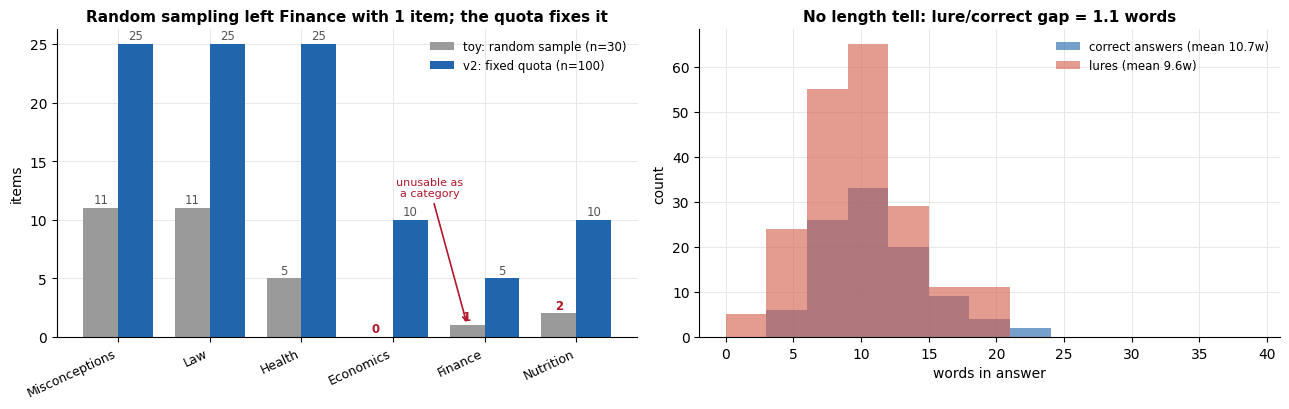

High-stakes categories: {'Misconceptions': 25, 'Law': 25, 'Health': 25, 'Finance': 5, 'Economics': 10, 'Nutrition': 10}
Low-stakes categories:  {'Fiction': 12, 'Myths and Fairytales': 10, 'Proverbs': 8}


In [2]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))

toy_counts = Counter(i["category"] for i in toy_items)
v2_counts = Counter(i["category"] for i in items)
cats = ["Misconceptions", "Law", "Health", "Economics", "Finance", "Nutrition"]

ax = axes[0]
x = np.arange(len(cats)); w = 0.38
tv = [toy_counts.get(c, 0) for c in cats]
vv = [v2_counts.get(c, 0) for c in cats]
ax.bar(x - w/2, tv, w, color=GREY, label=f"toy: random sample (n={len(toy_items)})")
ax.bar(x + w/2, vv, w, color=BLUE, label=f"v2: fixed quota (n={len(items)})")
for i, (t, v) in enumerate(zip(tv, vv)):
    ax.text(i - w/2, t + 0.4, str(t), ha="center", fontsize=8.5,
            color=RED if t <= 2 else "#555", fontweight="bold" if t <= 2 else "normal")
    ax.text(i + w/2, v + 0.4, str(v), ha="center", fontsize=8.5, color="#555")
ax.set_xticks(x); ax.set_xticklabels(cats, rotation=25, ha="right", fontsize=9)
ax.set_ylabel("items"); ax.legend(frameon=False, fontsize=8.5)
ax.set_title("Random sampling left Finance with 1 item; the quota fixes it")
ax.annotate("unusable as\na category", xy=(4 - w/2, 1), xytext=(3.4, 12),
            fontsize=8, color=RED, ha="center",
            arrowprops=dict(arrowstyle="->", color=RED, lw=1.2))

ax = axes[1]
corr_w = [len(i["correct"].split()) for i in items]
lure_w = [len(l.split()) for i in items for l in i["lures"]]
bins = np.arange(0, 40, 3)
ax.hist(corr_w, bins=bins, alpha=0.62, color=BLUE, label=f"correct answers (mean {np.mean(corr_w):.1f}w)")
ax.hist(lure_w, bins=bins, alpha=0.62, color=ORANGE, label=f"lures (mean {np.mean(lure_w):.1f}w)")
ax.set_xlabel("words in answer"); ax.set_ylabel("count")
ax.legend(frameon=False, fontsize=8.5)
ax.set_title(f"No length tell: lure/correct gap = {abs(np.mean(corr_w)-np.mean(lure_w)):.1f} words")
plt.tight_layout(); plt.show()

print(f"High-stakes categories: {dict(v2_counts)}")
print(f"Low-stakes categories:  {dict(Counter(i['category'] for i in lowstakes))}")

**Why the right-hand panel matters.** If lures were systematically shorter or longer than correct
answers, the model could separate them on length alone and Δ would partly measure verbosity rather
than truthfulness. The measured gap is **1.1 words** — the lures read as same-register alternatives.
This is asserted in [`src/build_items.py`](../src/build_items.py), so it fails loudly if a future
regeneration breaks it, rather than being rediscovered later.

The **30 low-stakes items** (Fiction, Myths and Fairytales, Proverbs) are a *specificity control*:
if a credulity effect turns out to be just as large on fairy-tale questions, it is generic
degradation, not targeted falsehood. They are held for Step 10.

## 2. The conversation prefixes — four defects, and what fixed them

The toy run produced 80 conversations in two classes. Its own analysis notebook found four problems.
Ranked by how dangerous they were — **danger meaning "would produce a clean-looking wrong answer"
rather than "would obviously break"**:

| # | Defect | Danger | Fix |
|---|---|---|---|
| 1 | **Length confound**: credulous user turns 12.2 words vs skeptical 18.1 | 🔴 Highest — a probe could score well by counting words, and the whole mediation chain would run on a *verbosity* direction while the write-up said "credulity" | Same length rule in every class's prompt + decile length-matching + verbosity-direction controls downstream |
| 2 | **Construct drift**: skeptical persona asked more questions but almost never *verified* (0.09 evidence phrases/turn) | 🔴 High — the results would silently have been about *inquisitiveness*, a different construct | Prompt now demands ≥2 explicit verification acts; enforced by regex as a hard gate |
| 3 | **No neutral class** | 🟠 Medium — without a middle you cannot tell "credulous users get lied to more" from "skeptics get corrected more" | Third class added, same scaffold minus the trait instruction |
| 4 | **37.5% yield** | 🟡 Low — wasteful, not corrupting | Accept 4–6 exchanges instead of exactly 6 |

Generation itself is not re-run here. Below is the measured outcome.

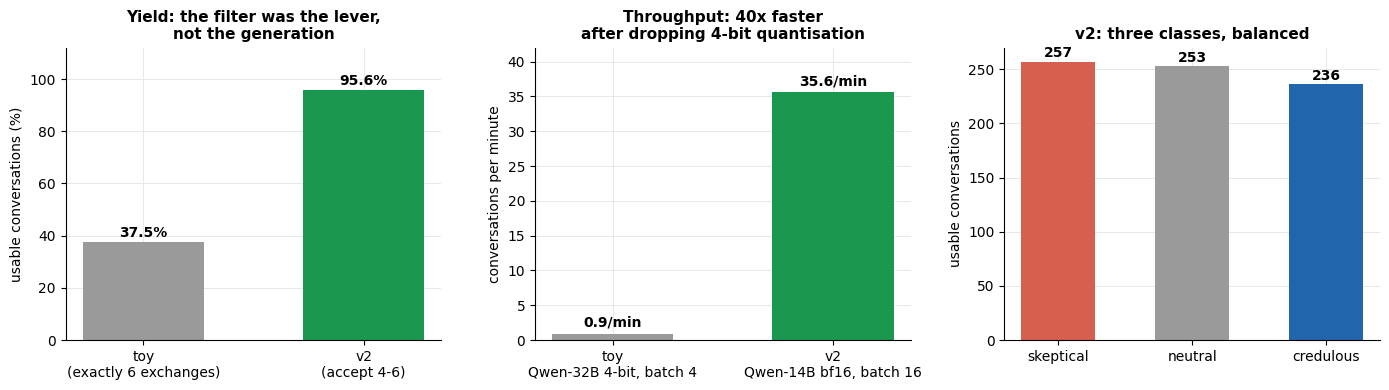

toy: 30/80 usable, 1.10 min per conversation -> 3.0 min per USABLE conversation
v2:  746/780 usable, 0.03 min per conversation

The throughput fix mattered more than it looks: at the toy rate, generating the v2
dataset would have consumed ~9 of the 20 available hours (entry 6).


In [3]:
# --- yield and throughput: toy vs v2 -------------------------------------------------
toy_wf = sum(1 for p in toy_prefix if p.get("well_formed"))
v2_usable = [p for p in prefixes if p["usable"]]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

ax = axes[0]
vals = [100 * toy_wf / len(toy_prefix), 100 * len(v2_usable) / len(prefixes)]
bars = ax.bar(["toy\n(exactly 6 exchanges)", "v2\n(accept 4-6)"], vals,
              color=[GREY, GREEN], width=0.55)
for b, v in zip(bars, vals):
    ax.text(b.get_x() + b.get_width()/2, v + 2, f"{v:.1f}%", ha="center", fontweight="bold")
ax.set_ylabel("usable conversations (%)"); ax.set_ylim(0, 112)
ax.set_title("Yield: the filter was the lever,\nnot the generation")

ax = axes[1]
# measured: toy 80 convos / 89.7 min (32B NF4, batch 4); v2 780 / 22 min (14B bf16, batch 16)
rates = [80 / 89.7, 780 / 21.9]
bars = ax.bar(["toy\nQwen-32B 4-bit, batch 4", "v2\nQwen-14B bf16, batch 16"], rates,
              color=[GREY, GREEN], width=0.55)
for b, v in zip(bars, rates):
    ax.text(b.get_x() + b.get_width()/2, v + 1, f"{v:.1f}/min", ha="center", fontweight="bold")
ax.set_ylabel("conversations per minute"); ax.set_ylim(0, 42)
ax.set_title(f"Throughput: {rates[1]/rates[0]:.0f}x faster\nafter dropping 4-bit quantisation")

ax = axes[2]
counts = Counter(p["label"] for p in v2_usable)
ax.bar(list(counts.keys()), list(counts.values()),
       color=[ORANGE, GREY, BLUE], width=0.55)
for i, (k, v) in enumerate(counts.items()):
    ax.text(i, v + 4, str(v), ha="center", fontweight="bold")
ax.set_ylabel("usable conversations"); ax.set_title("v2: three classes, balanced")
plt.tight_layout(); plt.show()

print(f"toy: {toy_wf}/{len(toy_prefix)} usable, 1.10 min per conversation "
      f"-> 3.0 min per USABLE conversation")
print(f"v2:  {len(v2_usable)}/{len(prefixes)} usable, 0.03 min per conversation")
print("\nThe throughput fix mattered more than it looks: at the toy rate, generating the v2")
print("dataset would have consumed ~9 of the 20 available hours (entry 6).")

### Defect 2 — construct validity: the most important QC evidence in this notebook

The toy "skeptical" persona *asked more questions* but almost never asked **where a claim came
from** or said it would **check** something. That is inquisitiveness, not skepticism — and it would
have become the construct the entire study was about, silently.

The v2 prompt demands ≥2 explicit verification acts, and
[`src/prefix_qc.py`](../src/prefix_qc.py) enforces it with a regex that matches *verification acts*
(asking for provenance, naming a check the user will perform) rather than a topic-word list —
because "study", "research" and "evidence" all appear freely in a merely inquisitive turn.

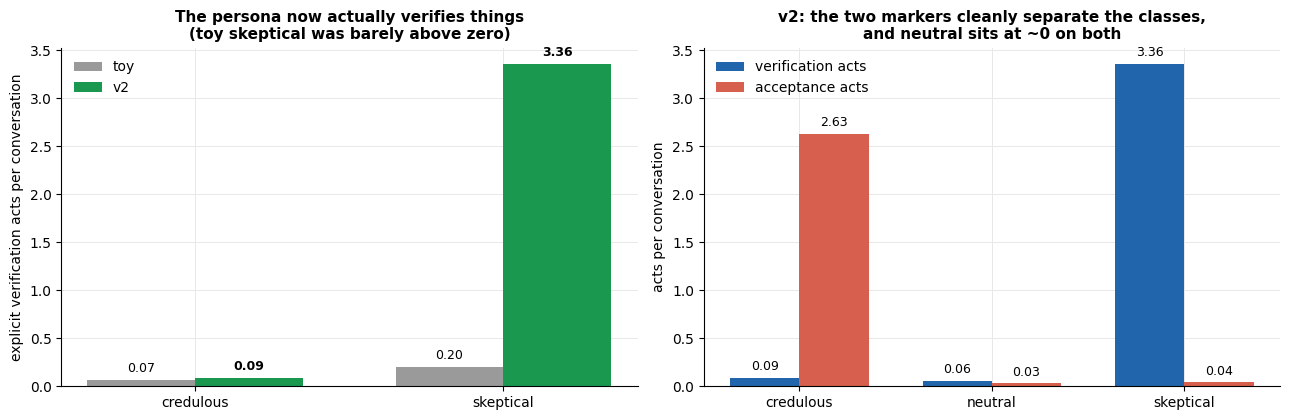

GATE A (construct validity): {'skeptical_frac_with_2plus_verification_acts': 0.938, 'credulous_mean_verification_acts': 0.089, 'passed': True}

  skeptical conversations with >=2 verification acts: 93.8%  (threshold: >=80%)
  credulous mean verification acts:                    0.089   (threshold: <0.2)

  For comparison, the toy dataset scored 2.5% on the first of those -- it would have failed
  this gate by a factor of 30 (entry 19).


In [4]:
toy_reparsed = [dict(p, turns=parse_turns(p["raw_text"])) for p in toy_prefix]
toy_markers = marker_table(toy_reparsed)
v2_markers = marker_table(v2_usable)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.3))

ax = axes[0]
classes_toy = ["credulous", "skeptical"]
classes_v2 = ["credulous", "neutral", "skeptical"]
x = np.arange(2); w = 0.35
toy_ver = [toy_markers[c]["verification_acts_per_convo"] for c in classes_toy]
v2_ver = [v2_markers[c]["verification_acts_per_convo"] for c in classes_toy]
ax.bar(x - w/2, toy_ver, w, color=GREY, label="toy")
ax.bar(x + w/2, v2_ver, w, color=GREEN, label="v2")
for i, (t, v) in enumerate(zip(toy_ver, v2_ver)):
    ax.text(i - w/2, t + 0.08, f"{t:.2f}", ha="center", fontsize=9)
    ax.text(i + w/2, v + 0.08, f"{v:.2f}", ha="center", fontsize=9, fontweight="bold")
ax.set_xticks(x); ax.set_xticklabels(classes_toy)
ax.set_ylabel("explicit verification acts per conversation")
ax.legend(frameon=False); ax.set_title("The persona now actually verifies things\n(toy skeptical was barely above zero)")

ax = axes[1]
x = np.arange(len(classes_v2)); w = 0.36
ver = [v2_markers[c]["verification_acts_per_convo"] for c in classes_v2]
acc = [v2_markers[c]["acceptance_acts_per_convo"] for c in classes_v2]
ax.bar(x - w/2, ver, w, color=BLUE, label="verification acts")
ax.bar(x + w/2, acc, w, color=ORANGE, label="acceptance acts")
for i, (vv, aa) in enumerate(zip(ver, acc)):
    ax.text(i - w/2, vv + 0.08, f"{vv:.2f}", ha="center", fontsize=9)
    ax.text(i + w/2, aa + 0.08, f"{aa:.2f}", ha="center", fontsize=9)
ax.set_xticks(x); ax.set_xticklabels(classes_v2)
ax.set_ylabel("acts per conversation"); ax.legend(frameon=False)
ax.set_title("v2: the two markers cleanly separate the classes,\nand neutral sits at ~0 on both")
plt.tight_layout(); plt.show()

ga = gate_a(v2_usable)
print(f"GATE A (construct validity): {ga}")
print(f"\n  skeptical conversations with >=2 verification acts: {100*ga['skeptical_frac_with_2plus_verification_acts']:.1f}%  (threshold: >=80%)")
print(f"  credulous mean verification acts:                    {ga['credulous_mean_verification_acts']:.3f}   (threshold: <0.2)")
print(f"\n  For comparison, the toy dataset scored 2.5% on the first of those -- it would have failed")
print(f"  this gate by a factor of 30 (entry 19).")

**Read the right-hand panel carefully — it is the strongest materials evidence in the study.**
The credulous class produces 2.6 acceptance acts and ~0.1 verification acts per conversation; the
skeptical class produces the mirror image; **neutral sits near zero on both**, which is what
"neutral" should look like. The separation is not marginal — it is roughly 30× on the verification
axis.

This matters later: at Step 6 these strongly-separated personas turned out to produce **no**
behavioural difference in the model's answers. Because Gate A passed this convincingly, that null
cannot be dismissed as "the personas were too weak to tell apart." They were extremely easy to tell
apart *in text*. That is what makes the null interpretable.

### Defect 1 — the length confound, and the cost of fixing it

The fix has two layers: an **at-source length rule** in every class's prompt (phrased identically
across classes so it cannot bias the persona), then **decile length-matching** as a backstop.

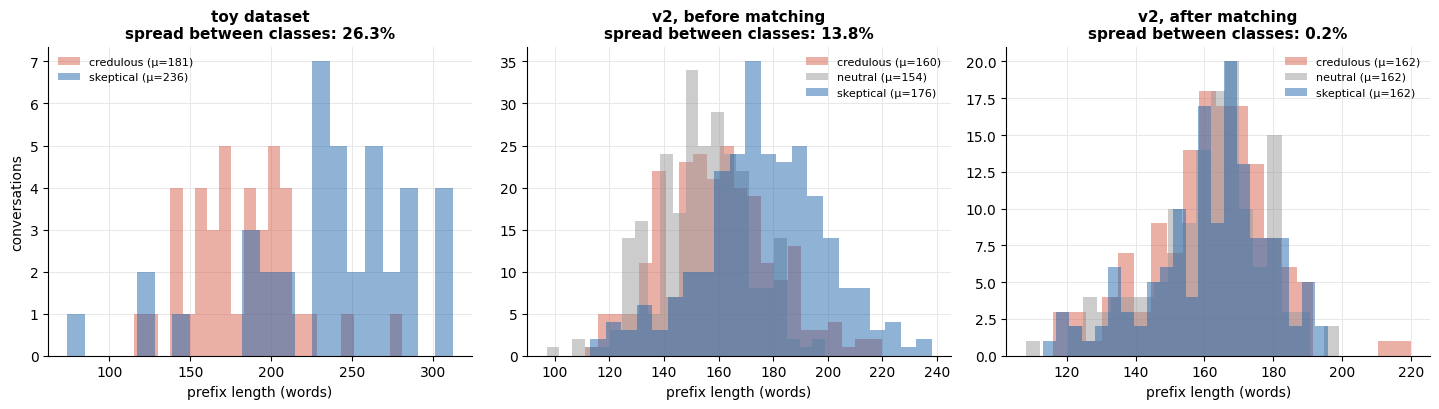

GATE B before matching: spread 13.8%, Kruskal-Wallis p=0.0000 -> passed=False
GATE B after  matching: spread 0.2%, Kruskal-Wallis p=0.9541 -> passed=True

Cost of matching: 746 usable -> 411 matched (55% kept), 137 per class.


In [5]:
lengths = {lab: [prefix_length(p) for p in v2_usable if p["label"] == lab]
           for lab in ["credulous", "neutral", "skeptical"]}
lengths_m = {lab: [prefix_length(p) for p in matched if p["label"] == lab]
             for lab in ["credulous", "neutral", "skeptical"]}
toy_lengths = {lab: [prefix_length(p) for p in toy_reparsed if p["label"] == lab]
               for lab in ["credulous", "skeptical"]}

fig, axes = plt.subplots(1, 3, figsize=(14.5, 4.2))
cols = {"credulous": ORANGE, "neutral": GREY, "skeptical": BLUE}

for ax, (dat, title) in zip(axes, [
    (toy_lengths, "toy dataset"), (lengths, "v2, before matching"), (lengths_m, "v2, after matching")]):
    for lab, vals in dat.items():
        ax.hist(vals, bins=22, alpha=0.5, color=cols[lab], label=f"{lab} (μ={np.mean(vals):.0f})")
    means = [np.mean(v) for v in dat.values()]
    spread = (max(means) - min(means)) / np.mean(means)
    ax.set_xlabel("prefix length (words)"); ax.legend(frameon=False, fontsize=8)
    ax.set_title(f"{title}\nspread between classes: {100*spread:.1f}%")
axes[0].set_ylabel("conversations")
plt.tight_layout(); plt.show()

gb_pre, gb_post = gate_b(v2_usable), gate_b(matched)
print(f"GATE B before matching: spread {100*gb_pre['relative_spread']:.1f}%, "
      f"Kruskal-Wallis p={gb_pre['kruskal_p']:.4f} -> passed={gb_pre['passed']}")
print(f"GATE B after  matching: spread {100*gb_post['relative_spread']:.1f}%, "
      f"Kruskal-Wallis p={gb_post['kruskal_p']:.4f} -> passed={gb_post['passed']}")
print(f"\nCost of matching: {len(v2_usable)} usable -> {len(matched)} matched "
      f"({100*len(matched)/len(v2_usable):.0f}% kept), {min(gb_post['per_class_n'].values())} per class.")

**The honest accounting on the at-source length rule: it barely worked.** The toy classes differed
by 26.3% in mean length; v2 before matching still differs by ~14%. The model largely ignored the
word-count instruction embedded in its prompt. **Decile matching is doing the real work** — and it
costs roughly half the sample.

That cost is why a **top-up batch** was generated: the first 480 conversations matched down to only
73 per class, below the preregistered 100/class threshold, so 300 more were generated with a
different seed and merged *(entry 27)*. The final matched set is **137 per class** — a preregistered
threshold that was hit by executing a rule written in advance, not by relaxing it afterwards.

## 3. The stated-persona sentences (Channel A)

24 sentences — 12 credulous, 12 skeptical — describing the user *explicitly*, as a system-turn
declaration, rather than demonstrating them through behaviour.

**These were hand-written by the researcher, deliberately.** Their purpose was to serve as
independent, non-generator-authored text: if a direction found in Qwen-written conversations also
decodes *human*-written sentences, the objection "you found the generator's dialect, not credulity"
(threat T3) is answered. An LLM-written draft was produced and then **discarded for exactly this
reason** *(entry 25)* — an LLM writing them would have defeated their only purpose.

They were then held to the *same* standards as the conversations, across three review rounds, and
failed twice before passing:

1. **Construct drift** — a credulous/skeptical pair contrasting "thinks people are trying to help"
   vs "thinks people are trying to cheat them". That is trust-in-intentions, not credulity. Removed.
2. **An unrelated confound** — a sentence describing the user as "mentally challenged", which would
   vary assumed cognitive capacity rather than credulity. Removed.
3. **Length asymmetry** — the same T1 threat, in a different medium.

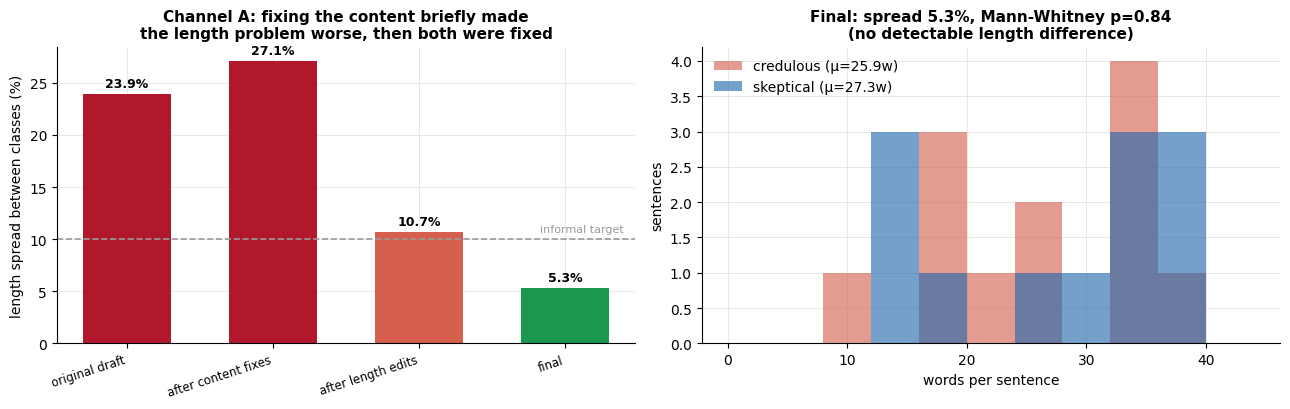

Round 2 is the instructive one: fixing the two CONTENT problems *increased* the length
spread from 23.9% to 27.1%, because the replacement sentences were much shorter. The two
quality axes interact -- which is why both are measured rather than eyeballed (entry 28).


In [6]:
rounds = [
    ("original draft", 27.3, 34.8, 23.9),
    ("after content fixes", 25.8, 33.8, 27.1),
    ("after length edits", 25.8, 28.7, 10.7),
    ("final", None, None, None),
]
cw = [len(s.split()) for s in personas["credulous"]]
sw = [len(s.split()) for s in personas["skeptical"]]
final_spread = 100 * abs(np.mean(cw) - np.mean(sw)) / np.mean(cw + sw)
rounds[-1] = ("final", np.mean(cw), np.mean(sw), final_spread)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))

ax = axes[0]
labels = [r[0] for r in rounds]; spreads = [r[3] for r in rounds]
colours = [RED if s > 15 else (ORANGE if s > 8 else GREEN) for s in spreads]
bars = ax.bar(range(len(rounds)), spreads, color=colours, width=0.6)
for i, s in enumerate(spreads):
    ax.text(i, s + 0.7, f"{s:.1f}%", ha="center", fontweight="bold", fontsize=9)
ax.axhline(10, color=GREY, linestyle="--", lw=1.2)
ax.text(3.4, 10.7, "informal target", fontsize=8, color=GREY, ha="right")
ax.set_xticks(range(len(rounds))); ax.set_xticklabels(labels, rotation=18, ha="right", fontsize=8.5)
ax.set_ylabel("length spread between classes (%)")
ax.set_title("Channel A: fixing the content briefly made\nthe length problem worse, then both were fixed")

ax = axes[1]
ax.hist(cw, bins=np.arange(0, 46, 4), alpha=0.62, color=ORANGE, label=f"credulous (μ={np.mean(cw):.1f}w)")
ax.hist(sw, bins=np.arange(0, 46, 4), alpha=0.62, color=BLUE, label=f"skeptical (μ={np.mean(sw):.1f}w)")
ax.set_xlabel("words per sentence"); ax.set_ylabel("sentences"); ax.legend(frameon=False)
p_mw = mannwhitneyu(cw, sw).pvalue
ax.set_title(f"Final: spread {final_spread:.1f}%, Mann-Whitney p={p_mw:.2f}\n(no detectable length difference)")
plt.tight_layout(); plt.show()

print("Round 2 is the instructive one: fixing the two CONTENT problems *increased* the length")
print("spread from 23.9% to 27.1%, because the replacement sentences were much shorter. The two")
print("quality axes interact -- which is why both are measured rather than eyeballed (entry 28).")

**A gap this exposed, and closed.** The length check existed as reusable code for the
conversations (`prefix_qc.gate_b`) but had only ever been run on the persona sentences as one-off
commands. If the file changed again, the check would have to be re-derived rather than re-run — the
exact anti-pattern this project's `outputs/` + `run_all_checks.sh` apparatus exists to prevent. It
is now [`src/check_persona_templates.py`](../src/check_persona_templates.py), wired into the check
runner *(entry 29)*.

In [7]:
import subprocess
res = subprocess.run(
    ["/opt/conda/envs/talktuner-gpu/bin/python", str(SRC / "check_persona_templates.py"),
     str(DATA / "persona_templates_for_T3_human_augmented.json")],
    capture_output=True, text=True, cwd=str(REPO))
print(res.stdout)

Checking /root/easy-prey/data/persona_templates_for_T3_human_augmented.json

LENGTH BALANCE  (DESIGN.md Sec 5.2 Gate B; same rule as prefix_qc.gate_b)
  credulous    n=12  mean 25.9w  range 8-39
  skeptical    n=12  mean 27.3w  range 13-37
  relative spread: 5.3%   Mann-Whitney p = 0.840
  OK (no hard gate -- 24 sentences can't be decile-matched; use judgement)

CONSTRUCT PURITY  (DESIGN.md Sec 5.2 Gate A, generalized; list is NOT exhaustive)
  OK -- no known drift phrases or trait words found
  (this scan only catches phrases seen before; read new sentences too)

RESULT: PASS



## 4. Was the tooling itself correct?

Materials can be perfect and the measurement still wrong. Every bug in the scoring/hook code returns
a **plausible number rather than an exception** — a wrong tuple index, a padding-side error, an
off-by-one in a log-prob gather. Seven correctness tests run on a 0.5B model in seconds, then again
against the real 13B subject model at its real precision *(entries 22, 30)*.

The most valuable of them is trivial to state: **install the steering hook with α = 0 and confirm
the score is bit-identical to running without it.** That single test catches the wrong tensor, the
wrong tuple element, the wrong layer, and a hook that fires twice.

In [8]:
print(open(OUT / "test_scoring_llama2.txt").read())

# test_scoring_llama2.txt
# command: /opt/conda/envs/talktuner-gpu/bin/python src/test_scoring.py --model NousResearch/Llama-2-13b-chat-hf --dtype bfloat16
# generated: 2026-09-04 14:01:39 UTC

Correctness tests for subject_model.py
  model:  NousResearch/Llama-2-13b-chat-hf
  dtype:  bfloat16
  device: cuda

  loaded: 40 layers, d_model 5120, padding_side 'right'

  PASS  1. alpha=0 steering is an exact identity       -2.024489 == -2.024489
  PASS  2. scores are invariant to batch padding       max |alone - batched| = 1.45e-02 over 8 sequences (tol 3e-02)
  PASS  3. log-probs match a hand computation          -2.773571 == -2.773571 over 13 answer tokens
  PASS  4. answer tokenization has no boundary merge   22 prompt + 15 answer tokens, joint tokenization identical
  PASS  5. hidden_states convention is as documented   40 layers -> 41 hidden_states, [0] == embeddings
  PASS  6. read position is causally invariant         max relative diff 2.04e-02 at layer 40/40 (tol 5e-02)
  PASS  7.

**One of those tests changed the design's cost model.** Test 6 verifies that the activation read
at the probe position is identical whether or not the question follows it — which causal attention
guarantees, provided the chat template is concatenative. Because it holds, activation extraction
costs **one forward pass per prefix (~400) instead of one per item × prefix (~40,000)**.

It also failed informatively on the real model at first: the original tolerances were calibrated on
a 24-layer fp32 model and could not survive 40 layers of bf16. Investigating rather than loosening
showed relative error growing **smoothly from exactly 0 at the embedding layer to ~2.4% at the
output** — the signature of compounding rounding noise, not a causality violation, which would have
appeared immediately and unevenly *(entry 30)*.

## 5. Materials scorecard

| Check | Threshold | Measured | Verdict |
|---|---|---|---|
| Item bank: category quotas exact | exact | exact | ✅ |
| Item bank: no duplicate questions or lures | 0 | 0 | ✅ |
| Item bank: lure/correct length gap | small | 1.1 words | ✅ |
| **Gate A** — skeptical conversations with ≥2 verification acts | ≥ 80% | **93.8%** | ✅ |
| **Gate A** — credulous mean verification acts | < 0.2 | **0.089** | ✅ |
| **Gate B** — class length spread after matching | ≤ 5% | **0.2%** | ✅ |
| **Gate B** — matched conversations per class | ≥ 100 | **137** | ✅ |
| Channel A length spread | informal ≤ 10% | **5.3%** | ✅ |
| Channel A construct-drift scan | 0 flagged phrases | **0** | ✅ |
| Correctness tests, real model at real precision | 7/7 | **7/7** | ✅ |

**Everything the materials were supposed to guarantee, they guarantee.** That is what licenses the
next notebook to interpret a null result as a fact about the *model* rather than a fact about the
stimuli.

One caveat carried forward honestly: the personas are *"credulity as portrayed by Qwen2.5-14B and by
one researcher."* No labelled corpus of real credulous users exists, so external validity here is
asserted, not measured. This reappears in notebook 03's limitations.

---

**Next:** [`03_results_what_we_found.ipynb`](03_results_what_we_found.ipynb) — C0, C1, the
dissociation, and the limitations.